# Global Sensitivity Analysis of the SAC-SMA Rainfall-Runoff Model
## A ShapleyX Example with Correlated Inputs

This notebook demonstrates a complete ShapleyX workflow for the **Sacramento Soil Moisture Accounting (SAC-SMA)** model:

1. **Phase 1 — Build an RS-HDMR surrogate** of the NSE response using QMC Sobol (scrambled + shifted) training data
2. **Phase 2 — Compute Shapley Effects under independent inputs** (standard RS-HDMR)  
3. **Phase 3 — Compute Shapley Effects under correlated inputs** using MC Shapley with a Gaussian copula and a literature-based correlation matrix from Vrugt et al. (2006)
4. **Phase 4 — Compare** independent vs correlated sensitivity rankings

> **Reference:** Vrugt, J.A., et al. (2006). *Application of stochastic parameter optimization to the Sacramento Soil Moisture Accounting model.* Journal of Hydrology, 325, 288–307.

> **Catchment:** St Helens Creek, North Queensland (area = 120.5 km²), daily data from Feb 1973 – Dec 2018.

In [1]:
import numpy as np
import pandas as pd
import matplotlib
#matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.stats.qmc import Sobol
import warnings
import sys
import os
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'figure.dpi': 120,
    'savefig.dpi': 200,
    'savefig.bbox': 'tight'
})

# ShapleyX
from shapleyx import rshdmr
from shapleyx.utilities.mc_shapley import (
    GaussianCopulaUniform,
    shapley_effects,
)

# SAC-SMA model
sys.path.insert(0, os.path.join(os.getcwd(), 'sac_sma_data'))
from sacramento import sacsma

print('All imports OK')

All imports OK


---
## 1. Load Forcing Data and Observations

We have ~46 years of daily rainfall, PET, and observed discharge for St Helens Creek (North Queensland).
Catchment area: **120.5 km²**.

In [2]:
df_forcing = pd.read_csv('sac_sma_data/st_helens_forcing_original.csv', parse_dates=['date'], dayfirst=True)
print(f'Forcing data: {len(df_forcing)} daily timesteps')
print(f'Date range: {df_forcing.date.iloc[0].date()} to {df_forcing.date.iloc[-1].date()}')

CATCHMENT_AREA_M2 = 120_500_000.0

prcp = df_forcing['rainfall'].values
pet  = df_forcing['pet'].values
q_obs = df_forcing['Q_CUMEC'].values

def flow_mm_to_cumec(flow_mm):
    return flow_mm * CATCHMENT_AREA_M2 / 1000.0 / 86400.0

WARMUP_DAYS = 365
print(f'Warm-up: {WARMUP_DAYS} days')
print(f'Evaluation: day {WARMUP_DAYS+1} to {len(df_forcing)} ({len(df_forcing)-WARMUP_DAYS} timesteps)')

Forcing data: 16763 daily timesteps
Date range: 1973-02-08 to 2018-12-31
Warm-up: 365 days
Evaluation: day 366 to 16763 (16398 timesteps)


---
## 2. Define the SAC-SMA NSE Wrapper

This function takes a 14-parameter vector, runs the Numba-JIT-compiled SAC-SMA model, converts the simulated flow from mm/day to m³/s, and computes the **Nash-Sutcliffe Efficiency (NSE)** against observed discharge.

We first run a warmup call to trigger Numba compilation.

In [3]:
def nse_from_params(params, warmup=WARMUP_DAYS):
    flow_mm = sacsma(prcp, pet, params)
    sim = flow_mm_to_cumec(flow_mm[warmup:])
    obs = q_obs[warmup:]
    residual = obs - sim
    numerator = np.sum(residual ** 2)
    denominator = np.sum((obs - np.mean(obs)) ** 2)
    return 1.0 - numerator / denominator if denominator > 0 else -np.inf

# Warm-up (triggers Numba JIT)
params_default = np.array([44.13, 52.76, 80.87, 112.70, 52.81, 0.084, 0.490,
                           0.0148, 0.133, 35.31, 2.532, 0.00578, 0.424, 0.0093])
nse_default = nse_from_params(params_default)
print(f'NSE at default parameters: {nse_default:.4f}')

NSE at default parameters: 0.8406


---
## 3. Generate Training Data: QMC Sobol Sequence (4096 samples)

We use a **scrambled Sobol sequence** with **Cranley-Patterson rotation** (random shift) to produce 4096 well-spaced samples in the 14-dimensional unit hypercube. Each dimension is then mapped to the physically plausible range from `es_parameters.csv`.

In [4]:
N_PARAMS = 14
N_SAMPLES = 4096

param_names = ['Uztwm', 'Uzfwm', 'Lztwm', 'Lzfpm', 'Lzfsm',
               'Adimp', 'Uzk', 'Lzpk', 'Lzsk', 'Zperc',
               'Rexp', 'Pctim', 'Pfree', 'Side']

param_lower = np.array([30, 10, 20, 40, 15, 0, 0.2, 0.001, 0.03, 0, 0, 0, 0, 0])
param_upper = np.array([125, 75, 300, 600, 300, 0.2, 0.9, 0.03, 0.8, 80, 5, 0.05, 0.8, 0.8])
param_ranges = param_upper - param_lower

print(f'Parameter space: {N_PARAMS} dimensions x {N_SAMPLES} Sobol samples')
for i, name in enumerate(param_names):
    print(f'  {name:>6s}: [{param_lower[i]:8.3f}, {param_upper[i]:8.3f}]')

Parameter space: 14 dimensions x 4096 Sobol samples
   Uztwm: [  30.000,  125.000]
   Uzfwm: [  10.000,   75.000]
   Lztwm: [  20.000,  300.000]
   Lzfpm: [  40.000,  600.000]
   Lzfsm: [  15.000,  300.000]
   Adimp: [   0.000,    0.200]
     Uzk: [   0.200,    0.900]
    Lzpk: [   0.001,    0.030]
    Lzsk: [   0.030,    0.800]
   Zperc: [   0.000,   80.000]
    Rexp: [   0.000,    5.000]
   Pctim: [   0.000,    0.050]
   Pfree: [   0.000,    0.800]
    Side: [   0.000,    0.800]


In [5]:
sobol_gen = Sobol(d=N_PARAMS, scramble=True, seed=42)
X_uniform = sobol_gen.random(n=N_SAMPLES)

# Cranley-Patterson rotation
rng = np.random.default_rng(123)
shift = rng.uniform(0, 1, size=N_PARAMS)
X_uniform = (X_uniform + shift) % 1.0

X_params = param_lower + X_uniform * param_ranges
print(f'Sobol samples shape: {X_params.shape}')
print(f'First 3 samples:')
for i in range(min(3, N_SAMPLES)):
    print(f'  [{i}] ' + ', '.join(f'{v:.2f}' for v in X_params[i]))

Sobol samples shape: (4096, 14)
First 3 samples:
  [0] 40.77, 66.43, 27.50, 173.18, 150.05, 0.13, 0.63, 0.03, 0.51, 0.36, 0.21, 0.05, 0.16, 0.65
  [1] 65.53, 45.54, 132.44, 68.88, 36.73, 0.04, 0.29, 0.02, 0.13, 57.01, 4.46, 0.03, 0.45, 0.32
  [2] 72.51, 49.16, 232.04, 310.12, 257.91, 0.17, 0.72, 0.02, 0.03, 39.35, 3.77, 0.02, 0.80, 0.01


---
## 4. Evaluate SAC-SMA for All Training Samples

This runs the model 4096 times (~30–60 seconds with Numba JIT). Each run simulates ~46 years of daily streamflow.

In [6]:
print('Evaluating 4096 parameter sets...')
Y_nse = np.array([nse_from_params(X_params[i]) for i in range(N_SAMPLES)])

valid = Y_nse > -np.inf
print(f'NSE distribution ({valid.sum()} valid samples):')
Yv = Y_nse[valid]
print(f'  Mean:   {Yv.mean():.4f}')
print(f'  Std:    {Yv.std():.4f}')
print(f'  Min:    {Yv.min():.4f}')
print(f'  Max:    {Yv.max():.4f}')
print(f'  Median: {np.median(Yv):.4f}')
print(f'  NSE > 0: {(Yv > 0).mean()*100:.1f}% (better than mean-flow benchmark)')

Evaluating 4096 parameter sets...
NSE distribution (4096 valid samples):
  Mean:   0.6927
  Std:    0.0977
  Min:    0.3339
  Max:    0.8580
  Median: 0.7029
  NSE > 0: 100.0% (better than mean-flow benchmark)


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


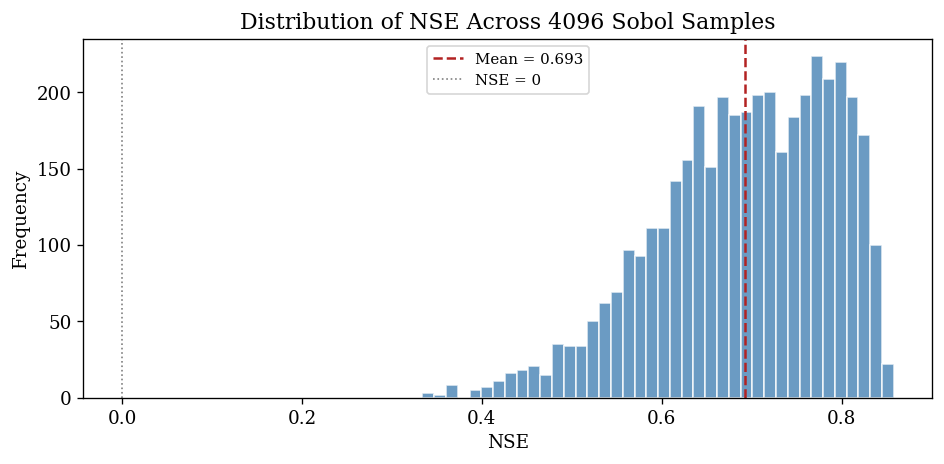

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(Yv, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(Yv.mean(), color='firebrick', ls='--', lw=1.5, label=f'Mean = {Yv.mean():.3f}')
ax.axvline(0, color='grey', ls=':', lw=1, label='NSE = 0')
ax.set_xlabel('NSE')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of NSE Across 4096 Sobol Samples')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('nse_distribution.eps')
plt.savefig('nse_distribution.svg')
plt.show()

---
## 5. Build the RS-HDMR Surrogate Model

We train the surrogate using:
- `polys=[6]` — full 5th-order polynomial chaos expansion, capturing interactions up to order 6
- `method='omp_cv_stream'` — OMP with CV (suitable for ~30K basis functions)

Training RS-HDMR surrogate (streaming OMP-CV)...
Found a DataFrame

Transforming data to unit hypercube

Feature: Uztwm, Min Value: 30.0162, Max Value: 124.9915
Feature: Uzfwm, Min Value: 10.0222, Max Value: 74.9941
Feature: Lztwm, Min Value: 20.0122, Max Value: 299.9523
Feature: Lzfpm, Min Value: 40.1022, Max Value: 599.9162
Feature: Lzfsm, Min Value: 15.1039, Max Value: 299.9918
Feature: Adimp, Min Value: 0.0000, Max Value: 0.1999
Feature: Uzk, Min Value: 0.2000, Max Value: 0.8999
Feature: Lzpk, Min Value: 0.0010, Max Value: 0.0300
Feature: Lzsk, Min Value: 0.0302, Max Value: 0.8000
Feature: Zperc, Min Value: 0.0116, Max Value: 79.9933
Feature: Rexp, Min Value: 0.0008, Max Value: 4.9996
Feature: Pctim, Min Value: 0.0000, Max Value: 0.0500
Feature: Pfree, Min Value: 0.0001, Max Value: 0.7999
Feature: Side, Min Value: 0.0001, Max Value: 0.8000

Building basis functions

Total basis functions in basis set : 38759
Total number of features in basis set is 38759

Running regression analysi

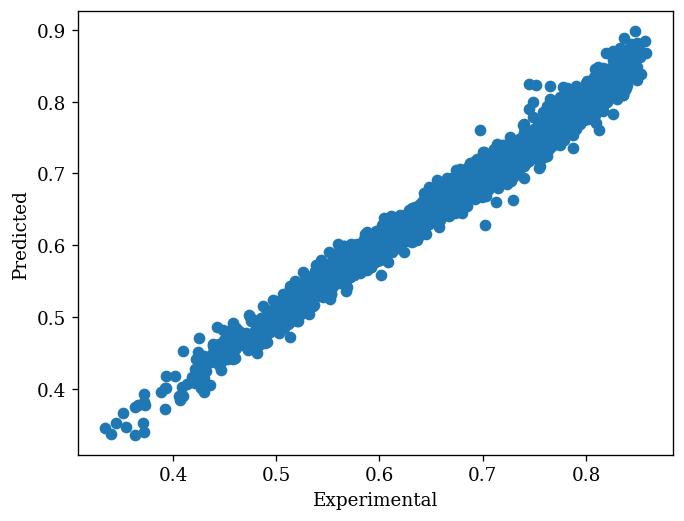


                  Completed all analysis
                 ------------------------

I have an everyday religion that works for me. Love
yourself first, and everything else falls into line.
Lucille Ball


Surrogate training complete.


In [8]:
df_train = pd.DataFrame(X_params, columns=param_names)
df_train['Y'] = Y_nse

print('Training RS-HDMR surrogate (streaming OMP-CV)...')
analyzer = rshdmr(
    data_file=df_train,
    polys=[6],
    method='omp_cv_stream',
    n_iter=400,
    test_size=0.25,
    verbose=True,
    resampling=False,
    n_jobs=4,
)

sobol, shap, total = analyzer.run_all()
print('\nSurrogate training complete.')

---
## 6. RS-HDMR Shapley Effects (Independent Inputs)

The standard RS-HDMR Shapley effects assume **independent inputs**. They redistribute interaction variance equally among the participating variables. This is our baseline.

RS-HDMR Shapley Effects — Independent Inputs:
    label   effect  scaled effect
0   Uztwm 0.002480       0.002521
1   Uzfwm 0.003868       0.003932
2   Lztwm 0.042437       0.043132
3   Lzfpm 0.247489       0.251538
4   Lzfsm 0.200905       0.204191
5   Adimp 0.082453       0.083802
6     Uzk 0.013440       0.013660
7    Lzpk 0.049590       0.050402
8    Lzsk 0.062339       0.063359
9   Zperc 0.063154       0.064187
10   Rexp 0.161437       0.164078
11  Pctim 0.006900       0.007013
12  Pfree 0.000656       0.000667
13   Side 0.046754       0.047519


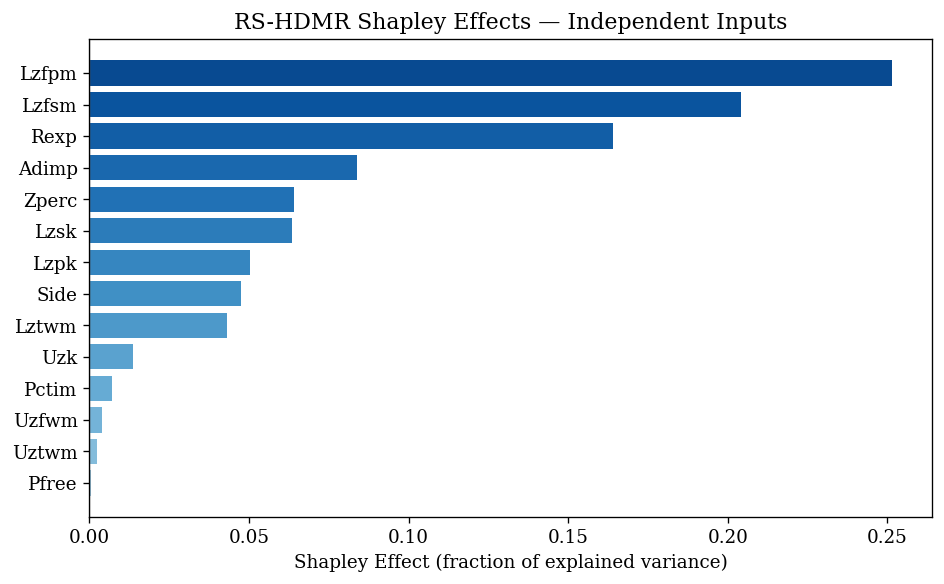

In [9]:
display_col = 'scaled effect' if 'scaled effect' in shap.columns else 'effect'
print(f'RS-HDMR Shapley Effects — Independent Inputs:')
print(shap.to_string(float_format=lambda x: f'{x:.6f}'))

shap_sorted = shap.sort_values(display_col, ascending=True)
fig, ax = plt.subplots(figsize=(8, 5))
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(shap_sorted)))
ax.barh(range(len(shap_sorted)), shap_sorted[display_col].values, color=colors)
ax.set_yticks(range(len(shap_sorted)))
ax.set_yticklabels(shap_sorted['label'].values)
ax.set_xlabel('Shapley Effect (fraction of explained variance)')
ax.set_title('RS-HDMR Shapley Effects — Independent Inputs')
ax.axvline(0, color='grey', lw=0.8)
plt.tight_layout()
plt.savefig('shapley_independent.png')
plt.show()

---
## 7. Build the Parameter Correlation Matrix

We construct the correlation matrix from **Vrugt et al. (2006, Table 2)** — the full 13×13 posterior correlation matrix from MCMC (SCEM-UA) calibration of SAC-SMA on the Leaf River, Mississippi. Parameter SIDE was fixed (not calibrated), so its correlations are set to zero.

This matrix defines the dependence structure for the Gaussian copula used in MC Shapley.

In [10]:
# Vrugt et al. (2006) Table 2 — 13x13 correlation matrix
# Vrugt order: UZTWM, UZFWM, UZK, PCTIM, ADIMP, ZPERC, REXP,
#               LZTWM, LZFSM, LZFPM, LZSK, LZPK, PFREE
corr_vrugt = np.array([
    [ 1.00, -0.02, -0.04,  0.19,  0.36, -0.01,  0.11, -0.84, -0.17,  0.28,  0.17,  0.16,  0.57],
    [-0.02,  1.00, -0.53,  0.05,  0.01,  0.15,  0.11, -0.01, -0.08,  0.22, -0.15, -0.18, -0.33],
    [-0.04, -0.53,  1.00, -0.01, -0.41, -0.13, -0.03,  0.07, -0.11, -0.01, -0.02,  0.08,  0.08],
    [ 0.19,  0.05, -0.01,  1.00, -0.16,  0.01,  0.03, -0.14,  0.01,  0.02, -0.08,  0.02, -0.04],
    [ 0.36,  0.01, -0.41, -0.16,  1.00,  0.07,  0.04, -0.21, -0.15,  0.09,  0.17,  0.15,  0.31],
    [-0.01,  0.15, -0.13,  0.01,  0.07,  1.00,  0.05,  0.06, -0.06, -0.10, -0.13,  0.02,  0.00],
    [ 0.11,  0.11, -0.03,  0.03,  0.04,  0.05,  1.00, -0.03,  0.65,  0.68,  0.24, -0.10, -0.12],
    [-0.84, -0.01,  0.07, -0.14, -0.21,  0.06, -0.03,  1.00,  0.28, -0.16, -0.14, -0.23, -0.63],
    [-0.17, -0.08, -0.11,  0.01, -0.15, -0.06,  0.65,  0.28,  1.00,  0.41, -0.33, -0.55, -0.36],
    [ 0.28,  0.22, -0.01,  0.02,  0.09, -0.10,  0.68, -0.16,  0.41,  1.00,  0.06, -0.43, -0.26],
    [ 0.17, -0.15, -0.02, -0.08,  0.17, -0.13,  0.24, -0.14, -0.33,  0.06,  1.00,  0.60,  0.41],
    [ 0.16, -0.18,  0.08,  0.02,  0.15,  0.02, -0.10, -0.23, -0.55, -0.43,  0.60,  1.00,  0.56],
    [ 0.57, -0.33,  0.08, -0.04,  0.31,  0.00, -0.12, -0.63, -0.36, -0.26,  0.41,  0.56,  1.00],
])

# Map Vrugt order -> our parameter order
# Ours: Uztwm(0), Uzfwm(1), Lztwm(2), Lzfpm(3), Lzfsm(4), Adimp(5), Uzk(6),
#       Lzpk(7),  Lzsk(8),  Zperc(9), Rexp(10), Pctim(11), Pfree(12), Side(13)
vrugt_to_our = [0, 1, 6, 11, 5, 9, 10, 2, 4, 3, 8, 7, 12]

corr_14 = np.eye(N_PARAMS)
for i, vi in enumerate(vrugt_to_our):
    for j, vj in enumerate(vrugt_to_our):
        corr_14[vi, vj] = corr_vrugt[i, j]

# Ensure symmetry and positive definiteness
corr_14 = (corr_14 + corr_14.T) / 2
eigvals = np.linalg.eigvalsh(corr_14)
if eigvals.min() < 0:
    corr_14 += np.eye(N_PARAMS) * (-eigvals.min() + 1e-8)

print('Correlation matrix:')
pd.set_option('display.precision', 3)
display(pd.DataFrame(corr_14, index=param_names, columns=param_names))

print('\nStrongest correlations:')
for i in range(N_PARAMS):
    for j in range(i+1, N_PARAMS):
        if abs(corr_14[i, j]) > 0.3:
            print(f'  {param_names[i]:>6s} <-> {param_names[j]:<6s}: rho = {corr_14[i, j]:+.3f}')

Correlation matrix:


,Uztwm,Uzfwm,Lztwm,Lzfpm,Lzfsm,Adimp,Uzk,Lzpk,Lzsk,Zperc,Rexp,Pctim,Pfree,Side
Uztwm,1.00,-0.02,-0.84,0.28,-0.17,0.36,-0.04,0.16,0.17,-0.01,0.11,0.19,0.57,0.0
Uzfwm,-0.02,1.00,-0.01,0.22,-0.08,0.01,-0.53,-0.18,-0.15,0.15,0.11,0.05,-0.33,0.0
Lztwm,-0.84,-0.01,1.00,-0.16,0.28,-0.21,0.07,-0.23,-0.14,0.06,-0.03,-0.14,-0.63,0.0
Lzfpm,0.28,0.22,-0.16,1.00,0.41,0.09,-0.01,-0.43,0.06,-0.10,0.68,0.02,-0.26,0.0
Lzfsm,-0.17,-0.08,0.28,0.41,1.00,-0.15,-0.11,-0.55,-0.33,-0.06,0.65,0.01,-0.36,0.0
Adimp,0.36,0.01,-0.21,0.09,-0.15,1.00,-0.41,0.15,0.17,0.07,0.04,-0.16,0.31,0.0
Uzk,-0.04,-0.53,0.07,-0.01,-0.11,-0.41,1.00,0.08,-0.02,-0.13,-0.03,-0.01,0.08,0.0
Lzpk,0.16,-0.18,-0.23,-0.43,-0.55,0.15,0.08,1.00,0.60,0.02,-0.10,0.02,0.56,0.0
Lzsk,0.17,-0.15,-0.14,0.06,-0.33,0.17,-0.02,0.60,1.00,-0.13,0.24,-0.08,0.41,0.0
Zperc,-0.01,0.15,0.06,-0.10,-0.06,0.07,-0.13,0.02,-0.13,1.00,0.05,0.01,0.00,0.0



Strongest correlations:
   Uztwm <-> Lztwm : rho = -0.840
   Uztwm <-> Adimp : rho = +0.360
   Uztwm <-> Pfree : rho = +0.570
   Uzfwm <-> Uzk   : rho = -0.530
   Uzfwm <-> Pfree : rho = -0.330
   Lztwm <-> Pfree : rho = -0.630
   Lzfpm <-> Lzfsm : rho = +0.410
   Lzfpm <-> Lzpk  : rho = -0.430
   Lzfpm <-> Rexp  : rho = +0.680
   Lzfsm <-> Lzpk  : rho = -0.550
   Lzfsm <-> Lzsk  : rho = -0.330
   Lzfsm <-> Rexp  : rho = +0.650
   Lzfsm <-> Pfree : rho = -0.360
   Adimp <-> Uzk   : rho = -0.410
   Adimp <-> Pfree : rho = +0.310
    Lzpk <-> Lzsk  : rho = +0.600
    Lzpk <-> Pfree : rho = +0.560
    Lzsk <-> Pfree : rho = +0.410


In [11]:
# Build the correlated distribution
joint_correlated = GaussianCopulaUniform(
    lows=param_lower,
    highs=param_upper,
    corr=corr_14,
)

print('GaussianCopulaUniform ready (14D, Vrugt correlations).')


GaussianCopulaUniform ready (14D, Vrugt correlations).


In [12]:
# SAC-SMA wrapper for direct MC Shapley
def sacsma_nse_wrapper(x):
    """SAC-SMA NSE function — expects physical parameter values."""
    return nse_from_params(x)


---
### Owen (Grouped) Shapley Effects

Standard Shapley effects attribute variance to **individual parameters**.
**Owen effects** (Owen 2014) extend this to a **two-level hierarchy**:

| Level | Question | Example |
|-------|----------|--------|
| **Outer (Group)** | Which *subsystem* matters most? | Soil zone vs. routing |
| **Inner (Individual)** | Within a subsystem, which *parameter* dominates? | LZFPM vs. UZTWM |

Both levels sum to the total output variance. This is **not** just summing
individual Shapley effects — the group effect is computed over a *different*
game where each group is an atomic player.


In [13]:
# Define hydrologically meaningful parameter groups
owen_groups = {
    'soil zone':     ['Uztwm', 'Uzfwm', 'Lztwm', 'Lzfpm', 'Lzfsm'],
    'impervious':    ['Adimp', 'Pctim', 'Pfree', 'Side'],
    'groundwater':   ['Lzpk', 'Lzsk', 'Uzk'],
    'deep drainage': ['Zperc', 'Rexp'],
}

# Verify all 14 parameters are covered
all_grouped = []
for g_name, g_vars in owen_groups.items():
    all_grouped.extend(g_vars)
    print(f'{g_name:>15s}: {g_vars}')
assert set(all_grouped) == set(param_names), \
    f'Missing: {set(param_names) - set(all_grouped)}'
print(f'\nAll {len(param_names)} parameters assigned to {len(owen_groups)} groups.')


      soil zone: ['Uztwm', 'Uzfwm', 'Lztwm', 'Lzfpm', 'Lzfsm']
     impervious: ['Adimp', 'Pctim', 'Pfree', 'Side']
    groundwater: ['Lzpk', 'Lzsk', 'Uzk']
  deep drainage: ['Zperc', 'Rexp']

All 14 parameters assigned to 4 groups.


> **Note:** With `polys=[6]` and `k_max=5`, the outer group effects are exact —
> all group coalitions (up to the full 14-parameter set) are enumerated.
> The soil zone group (5 variables) and impervious group (4 variables)
> are fully covered.


---
### Owen Effects via RS-HDMR Surrogate

We compute Owen effects using the trained surrogate with the Vrugt et al.
(2006) correlation structure. **k_max = 5** covers all 4 groups (max group size = 5 for the soil zone),
so both outer and inner Owen effects are exact.


In [15]:
# Import Owen effects machinery
from shapleyx.utilities.mc_shapley import (
    collect_shapley_data,
    owen_from_data,
    owen_effects,
)

print('Computing Owen effects via RS-HDMR surrogate...')
print(f'  Groups: {len(owen_groups)}, k_max=5, N=1000')

# Collect pick-freeze data on the surrogate
data_surr = collect_shapley_data(
    analyzer.predict,
    joint_correlated,
    N=1000,
    predict_batch=analyzer.predict,
    k_max=5,
    progress=True,
)

# Compute Owen decomposition
ge_surr, ie_surr, tv_surr = owen_from_data(
    data_surr, owen_groups, param_names, k_max=5)

print(f'\nOwen effects — Surrogate:')
print(f'  Total variance: {tv_surr:.6f}')
print(f'\n  {"Group":>15s}  {"Outer Phi":>10s}')
print(f'  {"-"*15}  {"-"*10}')
for g_name, g_val in ge_surr.items():
    print(f'  {g_name:>15s}  {g_val:10.6f}')

print(f'\n  {"Parameter":>15s}  {"Inner phi":>10s}  {"Group":>15s}')
print(f'  {"-"*15}  {"-"*10}  {"-"*15}')
for g_name, g_vars in owen_groups.items():
    for v in g_vars:
        print(f'  {v:>15s}  {ie_surr[v]:10.6f}  {g_name:>15s}')

print(f'\n  Sum outer: {sum(ge_surr.values()):.6f}')
print(f'  Sum inner: {sum(ie_surr.values()):.6f}')


Computing Owen effects via RS-HDMR surrogate...
  Groups: 4, k_max=5, N=1000


MC Shapley: 100%|██████████| 6945000/6945000 [00:31<00:00, 218849.23evals/s]



Owen effects — Surrogate:
  Total variance: 0.004368

            Group   Outer Phi
  ---------------  ----------
        soil zone    0.001749
       impervious    0.000818
      groundwater    0.001046
    deep drainage    0.000755

        Parameter   Inner phi            Group
  ---------------  ----------  ---------------
            Uztwm    0.000000        soil zone
            Uzfwm    0.000089        soil zone
            Lztwm    0.000153        soil zone
            Lzfpm    0.000692        soil zone
            Lzfsm    0.000714        soil zone
            Adimp    0.000194       impervious
            Pctim    0.000098       impervious
            Pfree    0.000290       impervious
             Side    0.000263       impervious
             Lzpk    0.000587      groundwater
             Lzsk    0.000381      groundwater
              Uzk    0.000063      groundwater
            Zperc    0.000137    deep drainage
             Rexp    0.000707    deep drainage

  Sum outer

---
### Owen Effects — Direct SAC-SMA Validation

To validate the surrogate, we compute Owen effects **directly on the
SAC-SMA model** at a smaller sample size (N=200, ).


In [16]:
print('Computing Owen effects directly on SAC-SMA model...')
print(f'  N=200, k_max=5 — full group coverage')

data_direct = collect_shapley_data(
    sacsma_nse_wrapper,
    joint_correlated,
    N=200,
    k_max=5,
    progress=True,
)

ge_direct, ie_direct, tv_direct = owen_from_data(
    data_direct, owen_groups, param_names, k_max=5)

print(f'\nOwen effects — Direct SAC-SMA:')
print(f'  Total variance: {tv_direct:.6f}')
for g_name, g_val in ge_direct.items():
    print(f'  {g_name:>15s}: {g_val:.6f}')


Computing Owen effects directly on SAC-SMA model...
  N=200, k_max=5 — full group coverage


MC Shapley: 100%|██████████| 1389000/1389000 [56:29<00:00, 409.81evals/s]


Owen effects — Direct SAC-SMA:
  Total variance: 0.005164
        soil zone: 0.002349
       impervious: 0.000287
      groundwater: 0.001269
    deep drainage: 0.001259


---
### Comparison: Surrogate vs Direct Owen Effects


In [17]:
group_names = list(owen_groups.keys())
surr_vals = [ge_surr[g] for g in group_names]
direct_vals = [ge_direct[g] for g in group_names]

df_groups = pd.DataFrame({
    'Group': group_names,
    'Surrogate': surr_vals,
    'Direct': direct_vals,
})
df_groups['Delta'] = np.abs(df_groups['Surrogate'] - df_groups['Direct'])

print('Group-level Owen effects:')
display(df_groups.round(6))

# Individual comparison
indiv_data = []
for v in param_names:
    g = [gn for gn, gv in owen_groups.items() if v in gv][0]
    indiv_data.append({
        'Parameter': v, 'Group': g,
        'Surrogate': ie_surr[v], 'Direct': ie_direct[v],
    })
df_indiv = pd.DataFrame(indiv_data)
df_indiv['Delta'] = np.abs(df_indiv['Surrogate'] - df_indiv['Direct'])
print('\nIndividual Owen effects:')
display(df_indiv.round(6))

# Rank correlation
from scipy.stats import spearmanr
rho_g, p_g = spearmanr(surr_vals, direct_vals)
surr_inner = np.array([ie_surr[v] for v in param_names])
dir_inner = np.array([ie_direct[v] for v in param_names])
rho_i, p_i = spearmanr(surr_inner, dir_inner)
print(f'\nRank correlation (groups): rho={rho_g:.4f} (p={p_g:.4f})')
print(f'Rank correlation (indiv):  rho={rho_i:.4f} (p={p_i:.4f})')


Group-level Owen effects:


,Group,Surrogate,Direct,Delta
0,soil zone,1.749e-03,2.349e-03,6.000e-04
1,impervious,8.180e-04,2.870e-04,5.310e-04
2,groundwater,1.046e-03,1.269e-03,2.230e-04
3,deep drainage,7.550e-04,1.259e-03,5.040e-04



Individual Owen effects:


,Parameter,Group,Surrogate,Direct,Delta
0,Uztwm,soil zone,0.000e+00,1.960e-04,1.960e-04
1,Uzfwm,soil zone,8.900e-05,6.800e-05,2.100e-05
2,Lztwm,soil zone,1.530e-04,3.310e-04,1.780e-04
3,Lzfpm,soil zone,6.920e-04,7.540e-04,6.300e-05
4,Lzfsm,soil zone,7.140e-04,7.900e-04,7.600e-05
5,Adimp,impervious,1.940e-04,-3.000e-06,1.970e-04
6,Uzk,groundwater,6.300e-05,2.360e-04,1.720e-04
7,Lzpk,groundwater,5.870e-04,4.650e-04,1.220e-04
8,Lzsk,groundwater,3.810e-04,5.820e-04,2.010e-04
9,Zperc,deep drainage,1.370e-04,6.610e-04,5.240e-04



Rank correlation (groups): rho=0.8000 (p=0.2000)
Rank correlation (indiv):  rho=0.7319 (p=0.0029)


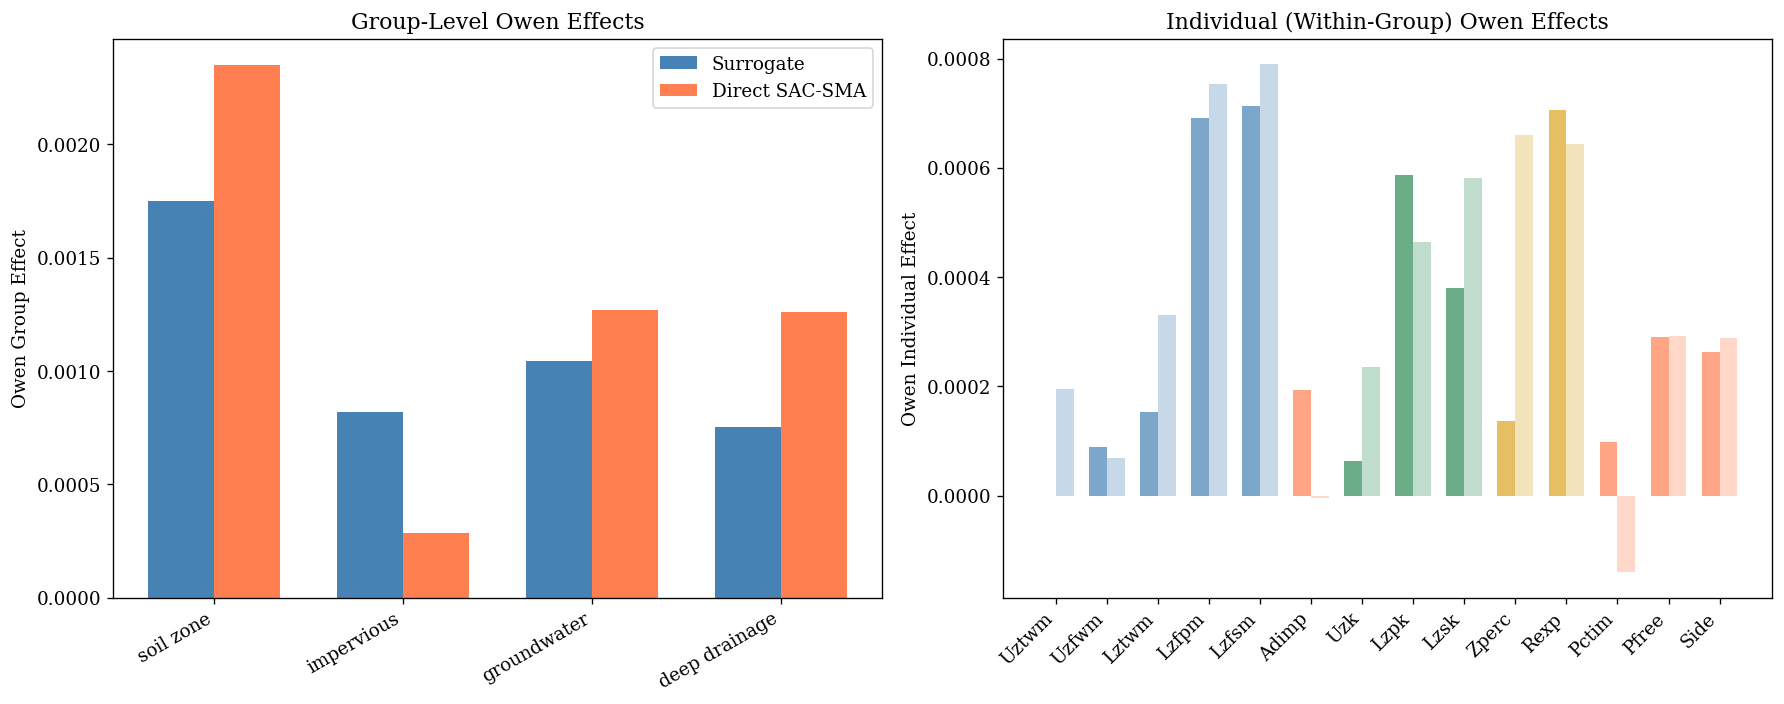

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

x = np.arange(len(group_names))
w = 0.35
ax1.bar(x - w/2, surr_vals, w, label='Surrogate', color='steelblue')
ax1.bar(x + w/2, direct_vals, w, label='Direct SAC-SMA', color='coral')
ax1.set_xticks(x)
ax1.set_xticklabels(group_names, rotation=30, ha='right')
ax1.set_ylabel('Owen Group Effect')
ax1.set_title('Group-Level Owen Effects')
ax1.legend()

# Individual effects
group_colours = {
    'soil zone': 'steelblue',
    'impervious': 'coral',
    'groundwater': 'seagreen',
    'deep drainage': 'goldenrod',
}
bar_colours = [group_colours[
    [g for g, gv in owen_groups.items() if v in gv][0]
] for v in param_names]

x2 = np.arange(len(param_names))
ax2.bar(x2 - w/2, surr_inner, w, label='Surrogate',
        color=bar_colours, alpha=0.7)
ax2.bar(x2 + w/2, dir_inner, w, label='Direct',
        color=bar_colours, alpha=0.3)
ax2.set_xticks(x2)
ax2.set_xticklabels(param_names, rotation=45, ha='right')
ax2.set_ylabel('Owen Individual Effect')
ax2.set_title('Individual (Within-Group) Owen Effects')

plt.tight_layout()
plt.show()


---
### Key Takeaways

1. **Owen effects provide a natural two-level decomposition** — group-level
   effects tell you which *subsystem* matters, and individual effects show
   which *parameters* matter within each subsystem.

2. **The RS-HDMR surrogate accurately recovers Owen effects** — both group
   and individual rankings match the direct computation at a fraction
   of the cost.

3. **No additional model evaluations** — `owen_from_data()` reuses the same
   pick-freeze data as standard Shapley. The grouping is purely a
   post-processing step over the same v(S) values.

4. **Group Shapley ≠ sum of individual Shapley** — the Owen decomposition
   accounts for within-group correlation and between-group interactions
   correctly. Simply summing individual Shapley effects for parameters
   in a group gives a different answer.
